# How to set up DIL using Dirichlet partitions

1. Download the dataset if not downloaded, otherwise use the one already available on the drive
2. Create the Federated dataset from flower and use the Dirichlet with 0.3 and a minimum size of partition being (total_size * (1-alpha))/(num_partitions) so 50000 images with 5 partitions and an alpha of 0.3 would yield a min size of 7000.
3. Split it into 80% train and 20% test for each partition. This should be done with random selection.
4. Make one train dataloader and one test dataloader per partition, shuffle being true for the train. Batch size should be large, at least 32. Up to 10 epochs per partition. (it would be 10 epochs of partition 1, then 10 epochs of partition 2, and so on)
5. Make the model - start with convnext
6. Set the optimizer (SGD) and loss fcn (nn.CrossEntropyLoss())
7. The training loop should do the training one partition at a time, tracking the accuracy of the model on all 5 test sets while going through training, as well as model plasticity and stability. Can also do DIL metrics, but this will be added after the initial setup.
8. Plot the accuracy of the model over time, with vertical lines where the partition shift occurs. Should have 6 lines: 5 lines being the accuracy of the 5 test sets over the full model training and 1 line that is the average accuracy over time over the full test set.

In [22]:
import os
import json

from collections import defaultdict
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader

import torchvision
from torchvision import transforms
from torchvision import models

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [23]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_path = os.path.join(os.getcwd(), 'datasets')

download = not (os.path.exists(os.path.join(dataset_path, 'cifar-10-batches-py')))

dataset_train = torchvision.datasets.CIFAR10(root=dataset_path, train=True, download=download, transform=transform)

def dirichlet_split(
    targets,
    num_partitions,
    alpha,
    min_size=10,
    balanced=False,
    seed=42,
    max_attempts=10
):
    """
    Split dataset indices into partitions using Dirichlet distribution.

    Args:
        targets (list or tensor): class labels
        num_partitions (int): number of partitions
        alpha (float): Dirichlet concentration parameter
        min_size (int): minimum number of samples per partition
        balanced (bool): if True, all partitions will have equal size
        seed (int)
        max_attempts (int)

    Returns:
        List[List[int]]: indices per partition
    """
    np.random.seed(seed)
    targets = np.array(targets)
    num_classes = len(np.unique(targets))
    N = len(targets)

    for attempt in range(max_attempts):
        class_indices = defaultdict(list)
        for idx, label in enumerate(targets):
            class_indices[label].append(idx)

        partitions = [[] for _ in range(num_partitions)]

        if balanced:
            # Compute target size per partition
            partition_size = N // num_partitions
            leftover = N - partition_size * num_partitions

            # Split class by class
            for c in range(num_classes):
                indices = np.array(class_indices[c])
                np.random.shuffle(indices)

                # Dirichlet proportions for this class
                proportions = np.random.dirichlet(alpha * np.ones(num_partitions))

                # Allocate number of samples per partition
                counts = (proportions * len(indices)).astype(int)

                # Fix rounding
                while counts.sum() < len(indices):
                    counts[np.argmax(counts)] += 1

                # Distribute indices
                start = 0
                for i in range(num_partitions):
                    partitions[i].extend(indices[start:start + counts[i]])
                    start += counts[i]

            # Adjust partitions to equal sizes
            for i in range(num_partitions):
                if len(partitions[i]) > partition_size:
                    partitions[i] = partitions[i][:partition_size]

            # Distribute leftover randomly
            leftover_indices = []
            for i in range(num_partitions):
                leftover_indices.extend(partitions[i][partition_size:])
            np.random.shuffle(leftover_indices)
            for i in range(leftover):
                partitions[i].append(leftover_indices.pop())

        else:
            # Unbalanced Dirichlet
            for c in range(num_classes):
                indices = np.array(class_indices[c])
                np.random.shuffle(indices)
                proportions = np.random.dirichlet(alpha * np.ones(num_partitions))
                counts = (proportions * len(indices)).astype(int)
                while counts.sum() < len(indices):
                    counts[np.argmax(counts)] += 1
                start = 0
                for i in range(num_partitions):
                    partitions[i].extend(indices[start:start + counts[i]])
                    start += counts[i]

        # Check min size constraint
        sizes = [len(p) for p in partitions]
        if min(sizes) >= min_size:
            return partitions

    raise RuntimeError(
        f"Failed to satisfy min_size={min_size} after {max_attempts} attempts"
    )

def dirichlet_partition_dataloaders(
    dataset,
    num_partitions,
    alpha,
    min_size=10,
    balanced=False,
    train_frac=0.8,
    batch_size=32,
    seed=42,
    max_attempts=10,
    shuffle=True
):
    """
    Split a PyTorch dataset into Dirichlet partitions, then split each
    partition into train/test and create DataLoaders.

    Args:
        dataset: PyTorch Dataset with 'targets' attribute (list or tensor)
        num_partitions: number of partitions
        alpha: Dirichlet concentration
        min_size: minimum samples per partition
        balanced: if True, partitions have equal size
        train_frac: fraction of each partition for training
        batch_size: DataLoader batch size
        seed: random seed
        max_attempts: max attempts to satisfy min_size
        shuffle: whether to shuffle train/test splits

    Returns:
        train_loaders: list of DataLoaders for training
        test_loaders: list of DataLoaders for testing
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Step 1: Dirichlet partition indices
    partitions_indices = dirichlet_split(
        dataset.targets,
        num_partitions=num_partitions,
        alpha=alpha,
        min_size=min_size,
        balanced=balanced,
        seed=seed,
        max_attempts=max_attempts
    )

    train_loaders = []
    test_loaders = []

    # Step 2: Split each partition into train/test
    for indices in partitions_indices:
        indices = np.array(indices)
        np.random.shuffle(indices)

        split_idx = int(len(indices) * train_frac)
        train_idx, test_idx = indices[:split_idx], indices[split_idx:]

        train_subset = Subset(dataset, train_idx)
        test_subset = Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=shuffle, pin_memory=True, num_workers=4, prefetch_factor=4)
        test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4, prefetch_factor=4)

        train_loaders.append(train_loader)
        test_loaders.append(test_loader)

    return train_loaders, test_loaders

/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


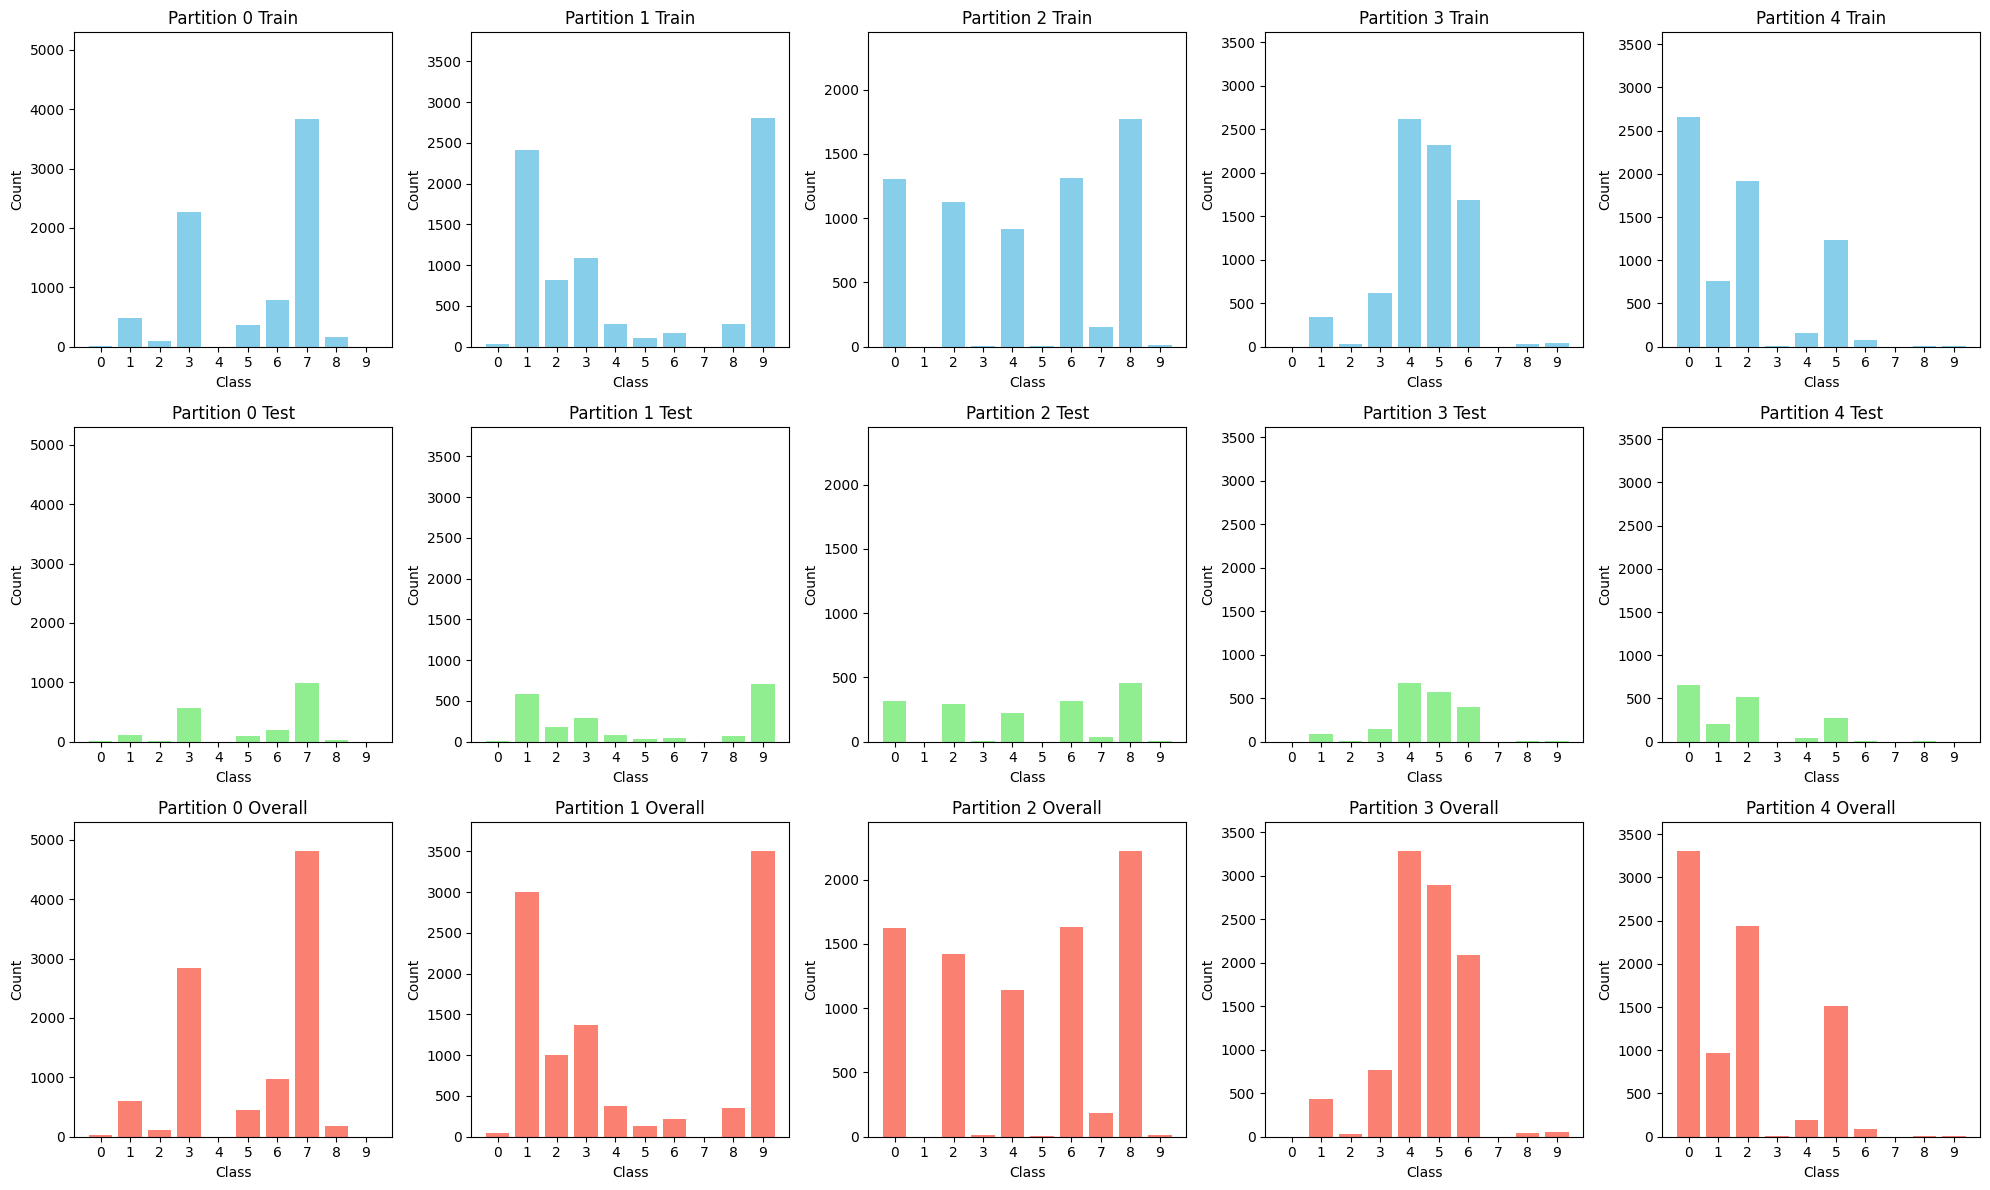

In [24]:
alpha = 0.3
num_partitions = 5
num_classes = 10
min_size = round(len(dataset_train.targets)*(1-alpha)/num_partitions)

train_frac = 0.8
batch_size = 128
seed = 1 # the meaning of life
shuffle = True
balanced = True

num_epochs_per_partition = 10

dirichlet = True

# Create partitions

if dirichlet:
    train_loaders, test_loaders = dirichlet_partition_dataloaders(
        dataset_train,
        num_partitions=num_partitions,
        alpha=alpha,
        min_size=min_size,
        balanced=True,
        train_frac=train_frac,
        batch_size=batch_size,
        seed=seed,
        max_attempts=10,
        shuffle=shuffle
        )
    
else:
    # Simple random split (balanced)
    indices = np.arange(len(dataset_train))
    np.random.shuffle(indices)
    split_idx = int(len(indices) * train_frac)

    train_indices = indices[:split_idx]
    test_indices = indices[split_idx:]

    train_subset = Subset(dataset_train, train_indices)
    test_subset = Subset(dataset_train, test_indices)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=shuffle, pin_memory=True, num_workers=4, prefetch_factor=2)
    test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, pin_memory=True, num_workers=4, prefetch_factor=2)

    train_loaders = [train_loader]
    test_loaders = [test_loader]

# Collect class distributions


def plot_partition_distributions(train_loaders, test_loaders, num_classes=10, class_names=None):
    """
    Plot class counts for each partition (train/test/overall).

    Args:
        train_loaders: list of DataLoaders for train
        test_loaders: list of DataLoaders for test
        num_classes: number of classes
        class_names: optional list of class names
    """
    num_partitions = len(train_loaders)

    fig, axes = plt.subplots(3, num_partitions, figsize=(4*num_partitions, 12))
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]

    for i in range(num_partitions):
        # Count train labels
        train_labels = []
        for _, labels in train_loaders[i]:
            train_labels.extend(labels.numpy())
        train_counts = [Counter(train_labels).get(c, 0) for c in range(num_classes)]

        # Count test labels
        test_labels = []
        for _, labels in test_loaders[i]:
            test_labels.extend(labels.numpy())
        test_counts = [Counter(test_labels).get(c, 0) for c in range(num_classes)]

        # Overall counts
        overall_counts = np.array(train_counts) + np.array(test_counts)

        # Plot train
        axes[0, i].bar(class_names, train_counts, color='skyblue')
        axes[0, i].set_title(f"Partition {i} Train")
        axes[0, i].set_ylim(0, max(overall_counts)*1.1)

        # Plot test
        axes[1, i].bar(class_names, test_counts, color='lightgreen')
        axes[1, i].set_title(f"Partition {i} Test")
        axes[1, i].set_ylim(0, max(overall_counts)*1.1)

        # Plot overall
        axes[2, i].bar(class_names, overall_counts, color='salmon')
        axes[2, i].set_title(f"Partition {i} Overall")
        axes[2, i].set_ylim(0, max(overall_counts)*1.1)

        for ax in axes[:, i]:
            ax.set_xlabel("Class")
            ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()


# Assuming you already created train_loaders and test_loaders
if dirichlet:
    plot_partition_distributions(train_loaders, test_loaders, num_classes=10)


In [25]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.cuda.empty_cache()

# ConvNeXt Tiny
model = models.convnext_tiny(pretrained=False, num_classes=10)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_per_partition)

def evaluate_accuracy(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/edgelab/imac/continous-MoE/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [26]:


save_dir = "./results"
os.makedirs(save_dir, exist_ok=True)

# --- Storage for metrics ---
accuracy_history = []
partition_shifts = []
plasticity_history = []
stability_history = []
average_incremental_accuracy = []

num_partitions = len(train_loaders)
best_domain_acc = np.zeros(num_partitions)
global_step = 0

for p_idx, train_dl in enumerate(train_loaders):
    partition_shifts.append(global_step)
    print(f"\nTraining on Partition {p_idx}")

    for epoch in range(num_epochs_per_partition):
        model.train()
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            global_step += 1

        scheduler.step()

        # Evaluate on all test partitions
        acc_dict = {}
        for i, test_dl in enumerate(test_loaders):
            acc = evaluate_accuracy(model, test_dl, device)
            acc_dict[i] = acc

        acc_dict['avg'] = np.mean(list(acc_dict.values()))
        accuracy_history.append(acc_dict)

        # Plasticity
        curr_acc = acc_dict[p_idx]
        plasticity = max(0, curr_acc - best_domain_acc[p_idx])
        best_domain_acc[p_idx] = max(best_domain_acc[p_idx], curr_acc)
        plasticity_history.append(plasticity)

        # Stability
        if p_idx == 0:
            stability = 1.0
        else:
            prev_acc = [acc_dict[i] for i in range(p_idx)]
            prev_best = [best_domain_acc[i] for i in range(p_idx)]
            stability = np.mean([a/b if b>0 else 1.0 for a,b in zip(prev_acc, prev_best)])
        stability_history.append(stability)

        # Average Incremental Accuracy (AIA): mean accuracy over **seen partitions only**
        seen_acc = [acc_dict[i] for i in range(p_idx+1)]
        aia = np.mean(seen_acc)
        average_incremental_accuracy.append(aia)

        print(f"Partition {p_idx} Epoch {epoch+1}: part_acc = {acc_dict[p_idx]:.4f} avg_acc={acc_dict['avg']:.4f}, plasticity={plasticity:.4f}, stability={stability:.4f}, AIA={aia:.4f}")



Training on Partition 0
Partition 0 Epoch 1: part_acc = 0.4905 avg_acc=0.1026, plasticity=0.4905, stability=1.0000, AIA=0.4905
Partition 0 Epoch 2: part_acc = 0.4905 avg_acc=0.1035, plasticity=0.0000, stability=1.0000, AIA=0.4905
Partition 0 Epoch 3: part_acc = 0.5005 avg_acc=0.1284, plasticity=0.0100, stability=1.0000, AIA=0.5005
Partition 0 Epoch 4: part_acc = 0.5295 avg_acc=0.1461, plasticity=0.0290, stability=1.0000, AIA=0.5295
Partition 0 Epoch 5: part_acc = 0.5180 avg_acc=0.1384, plasticity=0.0000, stability=1.0000, AIA=0.5180
Partition 0 Epoch 6: part_acc = 0.5130 avg_acc=0.1659, plasticity=0.0000, stability=1.0000, AIA=0.5130
Partition 0 Epoch 7: part_acc = 0.5495 avg_acc=0.1763, plasticity=0.0200, stability=1.0000, AIA=0.5495
Partition 0 Epoch 8: part_acc = 0.5510 avg_acc=0.1591, plasticity=0.0015, stability=1.0000, AIA=0.5510
Partition 0 Epoch 9: part_acc = 0.5450 avg_acc=0.1697, plasticity=0.0000, stability=1.0000, AIA=0.5450
Partition 0 Epoch 10: part_acc = 0.5490 avg_acc=

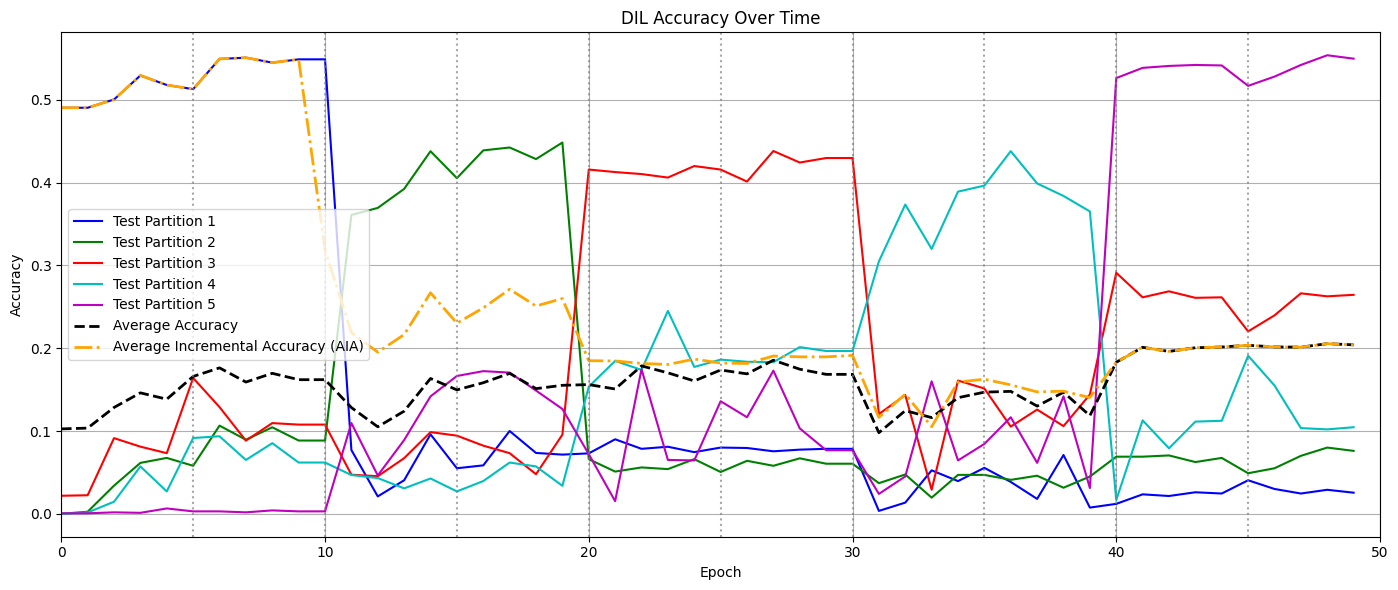

Figure saved to ./results/accuracy_over_time.png


In [27]:
steps = np.arange(len(accuracy_history))
accuracy_matrix = np.array([[a[i] for a in accuracy_history] for i in range(num_partitions)])
avg_accuracy = np.array([a['avg'] for a in accuracy_history])
aia_array = np.array(average_incremental_accuracy)
plasticity_array = np.array(plasticity_history)
stability_array = np.array(stability_history)

plt.figure(figsize=(14,6))

colors = ['b','g','r','c','m']
for i in range(num_partitions):
    plt.plot(steps, accuracy_matrix[i], label=f"Test Partition {i+1}", color=colors[i])

plt.plot(steps, avg_accuracy, label="Average Accuracy", color='k', linewidth=2, linestyle='--')
plt.plot(steps, aia_array, label="Average Incremental Accuracy (AIA)", color='orange', linewidth=2, linestyle='-.')

# Vertical lines for partition shifts
for shift in list(range(0, num_epochs_per_partition * num_partitions, num_partitions)):
    plt.axvline(x=shift, color='gray', linestyle=':', alpha=0.7)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DIL Accuracy Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0, num_epochs_per_partition * len(train_loaders))

# Save figure
fig_path = os.path.join(save_dir, "accuracy_over_time.png")
plt.savefig(fig_path)
plt.show()
print(f"Figure saved to {fig_path}")


In [28]:
metrics = {
    "accuracy_history": accuracy_history,
    "plasticity_history": plasticity_history,
    "stability_history": stability_history,
    "average_incremental_accuracy": average_incremental_accuracy,
    "partition_shifts": partition_shifts,
    "parameters": {
        "num_epochs_per_partition": num_epochs_per_partition,
        "train_frac": train_frac,
        "batch_size": batch_size,
        "alpha": alpha,
        "min_size": min_size,
        "balanced": balanced,
        "seed": seed,
        "num_partitions": num_partitions
    }
}

metrics_path = os.path.join(save_dir, "training_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"Metrics saved to {metrics_path}")


Metrics saved to ./results/training_metrics.json


In [29]:
print(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

cuda
